# Jiang & Oh 4.1.4 -- 1D CR diffusion

Visualization of `tests/cr/jiang_414/` (run by `run_cr_tests.sh`).


In [1]:
%matplotlib inline
import warnings; warnings.filterwarnings('ignore')
import os, numpy as np, matplotlib.pyplot as plt, osyris

path = os.path.abspath("../jiang_414")   # run outputs (edit if your tree differs)
title = "jiang_414"
panels = [('CRegy_01', '$e_c$', False), ('CRflx_01_x', '$F_c$', False)]
center = True        # shift x so the box is centred on 0
analytic = None    # 'triangular' overlays  E = 2 + (4/3) t - |x|


Processing 4 files in /Users/nlin/Work/ramses/ramses_cral/tests/cr/jiang_414/output_00001
 25% : read         64 cells,          0 particles
 50% : read        128 cells,          0 particles
 75% : read        192 cells,          0 particles
Loaded: 256 cells, 0 particles.
Processing 4 files in /Users/nlin/Work/ramses/ramses_cral/tests/cr/jiang_414/output_00002
 25% : read         64 cells,          0 particles
 50% : read        128 cells,          0 particles
 75% : read        192 cells,          0 particles
Loaded: 256 cells, 0 particles.
Processing 4 files in /Users/nlin/Work/ramses/ramses_cral/tests/cr/jiang_414/output_00003
 25% : read         64 cells,          0 particles
 50% : read        128 cells,          0 particles
 75% : read        192 cells,          0 particles
Loaded: 256 cells, 0 particles.


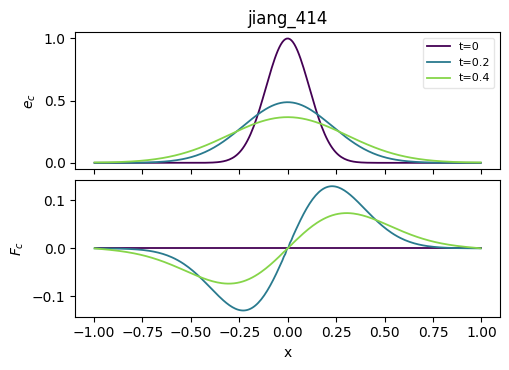

In [2]:
# Multi-panel profiles vs x, all snapshots overlaid.
def q(m, k):
    if k == "P_CR": return np.asarray(m["CRegy_01"].values) / 3.0   # CR pressure = e_c (gamma_cr-1)
    if k in m.keys(): return np.asarray(m[k].values)
    return np.asarray(getattr(m[k[:-2]], k[-1]).values)             # vector comp, e.g. velocity_x

snaps = sorted(int(d.split("_")[-1]) for d in os.listdir(path)
               if d.startswith("output_") and d.split("_")[-1].isdigit())
fig, axes = plt.subplots(len(panels), 1, figsize=(5.2, 1.9 * len(panels)), sharex=True)
if len(panels) == 1: axes = [axes]
cols = plt.cm.viridis(np.linspace(0.0, 0.82, len(snaps)))
for i, si in enumerate(snaps):
    d = osyris.RamsesDataset(si, path=path).load(); m = d["mesh"]
    t = d.meta["time"].magnitude
    x = q(m, "position_x"); srt = np.argsort(x)
    shift = 0.5 * (x.min() + x.max()) if center else 0.0
    for ax, (key, lab, ylog) in zip(axes, panels):
        ax.plot(x[srt] - shift, q(m, key)[srt], color=cols[i], lw=1.3, label=f"t={t:.3g}")
        ax.set_ylabel(lab)
        if ylog: ax.set_yscale("log")
    if analytic == "triangular" and t > 0:
        xa = np.linspace(x.min() - shift, x.max() - shift, 600)
        Ea = 2.0 + 4.0 / 3.0 * t - np.abs(xa)
        xm = np.sqrt(16.0 / 9.0 * t * (3.0 + t)); Ea[np.abs(xa) < xm] = 2.0 + 4.0 / 3.0 * t - xm
        axes[0].plot(xa, Ea, "k--", lw=0.9, label="analytic")
        Fa = np.zeros_like(xa); Fa[xa >= xm] = 4.0 / 3.0 * Ea[xa >= xm]; Fa[xa <= -xm] = -4.0 / 3.0 * Ea[xa <= -xm]
        axes[1].plot(xa, Fa, "k--", lw=0.9)
axes[0].legend(fontsize=8, framealpha=0.5); axes[-1].set_xlabel("x")
axes[0].set_title(title); fig.tight_layout(); plt.subplots_adjust(hspace=0.08)
plt.show()
